---
title: "Checking Numbers For Random"
description: "Testing the numbers created by my generator in my Flushtools library."
date: "2026-06-02"
categories: ["C++", "PRNG"]
---

# Evaluating Uniform Randomness in Procedural Generation Seeds

This dataset comprises a 100-million sample set generated by a custom pseudorandom number generator (PRNG) algorithm. The primary intent of this algorithm is to generate uniform random seeds for video game mechanics, procedural generation, and deterministic gameplay loops. 

The underlying implementation utilized to generate this specific sample set can be reviewed in the header files of the [flushtoolsh GitHub repository](https://github.com/flushwhy/flushtoolsh).

A 100-million sample distribution provides a robust dataset for testing empirical statistical behaviors against theoretical uniform distributions.

## Methodology & Testing Objectives

To validate that the algorithm successfully generates true uniform randomness without underlying patterns or bias, we will subject the dataset to four foundational statistical tests:
1. **Descriptive Statistics & Visual Inspection:** Analyzing basic metrics (Mean, Standard Deviation) and visualizing density using a binned histogram.
2. **Kolmogorov-Smirnov (K-S) Test:** Quantifying how closely the normalized empirical distribution matches a continuous theoretical uniform distribution.
3. **Runs Test for Randomness:** Evaluating serial independence to ensure sequential values show no systemic correlation or trend over time.
4. **Shannon Entropy:** Measuring the information density and unpredictability of the output space.

### Summary of Descriptive Statistics

The initial run provides the following key metrics for the raw dataset:
* **Mean:** $5.76 \times 10^{17}$
* **Standard Deviation:** $3.33 \times 10^{17}$

The histogram exhibits a flat, rectangular distribution across 50 bins, indicating high density equality across the entire range. With basic baseline uniformity established visually, we will now proceed to the **Kolmogorov-Smirnov (K-S) Test** for formal mathematical validation.

File: random_numbers.csv
Mean: 5.7644657733334925e+17
Standard Deviation: 3.3281965251579155e+17


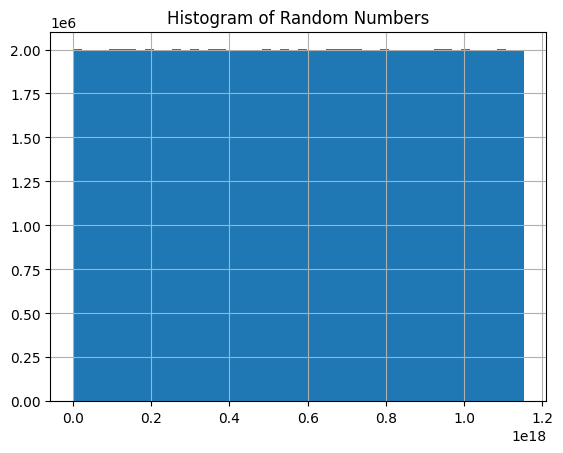

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        

        df = pd.read_csv(file_path)


        mean = df['RandomNumber'].mean()
        std_dev = df['RandomNumber'].std()

        print(f"File: {filename}")
        print(f"Mean: {mean}")
        print(f"Standard Deviation: {std_dev}")
        
        
        df['RandomNumber'].hist(bins=50)
        plt.title('Histogram of Random Numbers')
        plt.show()

### Statistical Interpretation: K-S and Sequential Independence

#### 1. Kolmogorov-Smirnov Test Results
* **K-S Statistic:** `6.211e-05`
* **P-Value:** `0.8351`

**Interpretation:** The K-S statistic measures the maximum distance between the empirical cumulative distribution and the theoretical uniform cumulative distribution. A value this close to 0 indicates an exceptionally tight fit. Combined with a high p-value ($p \approx 0.84$), we fail to reject the null hypothesis. The distribution is statistically indistinguishable from a true uniform distribution.

#### 2. Runs Test Results
* **Z-Score:** `0.9170`
* **P-Value:** `0.3591`

**Interpretation:** The Runs Test evaluates whether sequential numbers fluctuate around the mean randomly or if they form clusters/trends. The Z-score is well within the acceptable threshold ($-1.96 < Z < 1.96$), and the p-value ($p \approx 0.36$) indicates that the order of the generated numbers is thoroughly independent and unpredictable.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import kstest


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        df = pd.read_csv(file_path)

        normalized_numbers = (df['RandomNumber'] - df['RandomNumber'].min()) / (df['RandomNumber'].max() - df['RandomNumber'].min())
        ks_stat, ks_p_value = kstest(normalized_numbers, 'uniform')

        print(f"K-S Statistic: {ks_stat}")
        print(f"P-Value: {ks_p_value}")

K-S Statistic: 6.211061451166788e-05
P-Value: 0.8351403544799378


In [3]:
from statsmodels.sandbox.stats.runs import runstest_1samp
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        df = pd.read_csv(file_path)

        z, p_value = runstest_1samp(df['RandomNumber'], cutoff='mean')

        print(f"Runs Test Z-Score: {z}")
        print(f"Runs Test P-Value: {p_value}")

Runs Test Z-Score: 0.9170143700017832
Runs Test P-Value: 0.3591351100818988


In [4]:
from scipy.stats import entropy
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import chisquare
import os


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        df = pd.read_csv(file_path)

        # Calculate the probability distribution
        values, counts = np.unique(df['RandomNumber'], return_counts=True)
        probabilities = counts / counts.sum()

        # Calculate entropy
        entropy_value = entropy(probabilities)

print(f"Entropy: {entropy_value}")

Entropy: 18.420680743953362


## Final Assessment & Conclusion

#### 3. Entropy Analysis Results
* **Calculated Entropy:** `18.4207`

### Key Takeaways
The statistical battery yields excellent validation for this custom PRNG algorithm:
* **Uniformity:** Both visual density and the K-S test demonstrate that every value within the allocation range has an equal probability of occurrence.
* **Independence:** The Runs Test confirms the lack of predictable sequence patterns, meaning past seeds do not dictate future outcomes. 
* **High Information Density:** The Shannon Entropy score shows an incredibly high rate of uncertainty, maximizing the unpredictability required for game mechanics.

The algorithm demonstrates statistical soundness and is highly viable for integration into practical game engines and cryptographic seed generators.